# Student Performance Indicator

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [1]:
# required packages
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# avoiding warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# reading the csv file
from pathlib import Path
file = Path().cwd() / "data" / "stud.csv"

df = pd.read_csv(file)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape

(1000, 8)

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#### Handling the missing values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

>There are no missing values present

#### Handling the duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

>There are no duplicate row or column present

#### Handling the data types

In [8]:
df.dtypes

gender                         object
race_ethnicity                 object
parental_level_of_education    object
lunch                          object
test_preparation_course        object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

#### Checking the unique values

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

#### Checking the number statistics

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Average score for each subject**

Math score average: 66.09 \
Reading score average: 69.17 \
Writing score average: 68.05 \

**Insight**

Students perform best in reading, followed by writing, and slightly lower in math.

Order of performance:

```
Reading > Writing > Math
```

This suggests math might be the most challenging subject for students in this dataset.

#### Overview of the categorical data

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

NameError: name 'df' is not defined

In [12]:
for col in cat_cols:
    print(f"for the column {col} the unique values are : ", df[col].unique())

for the column gender the unique values are :  ['female' 'male']
for the column race_ethnicity the unique values are :  ['group B' 'group C' 'group A' 'group D' 'group E']
for the column parental_level_of_education the unique values are :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
for the column lunch the unique values are :  ['standard' 'free/reduced']
for the column test_preparation_course the unique values are :  ['none' 'completed']


#### Adding new features total score and average score


In [13]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average_score"] = df["total_score"] / 3

In [14]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### Understanding each column

#### Column 1: Gender

#### Univariate Analysis


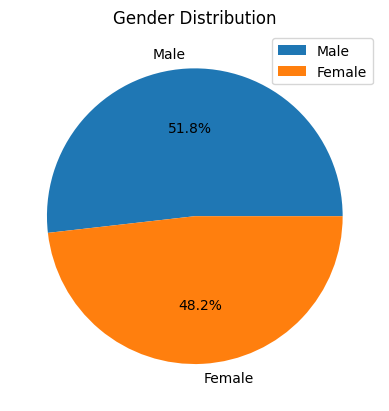

In [15]:
# # Gender Distribution
plt.pie(
    (df["gender"].value_counts() / df.shape[0]) * 100,
    labels=['Male','Female'],
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")
plt.legend()
plt.show()

> There are 52% Male Students and 48% female students

#### Bi variate analysis

<Axes: ylabel='average_score'>

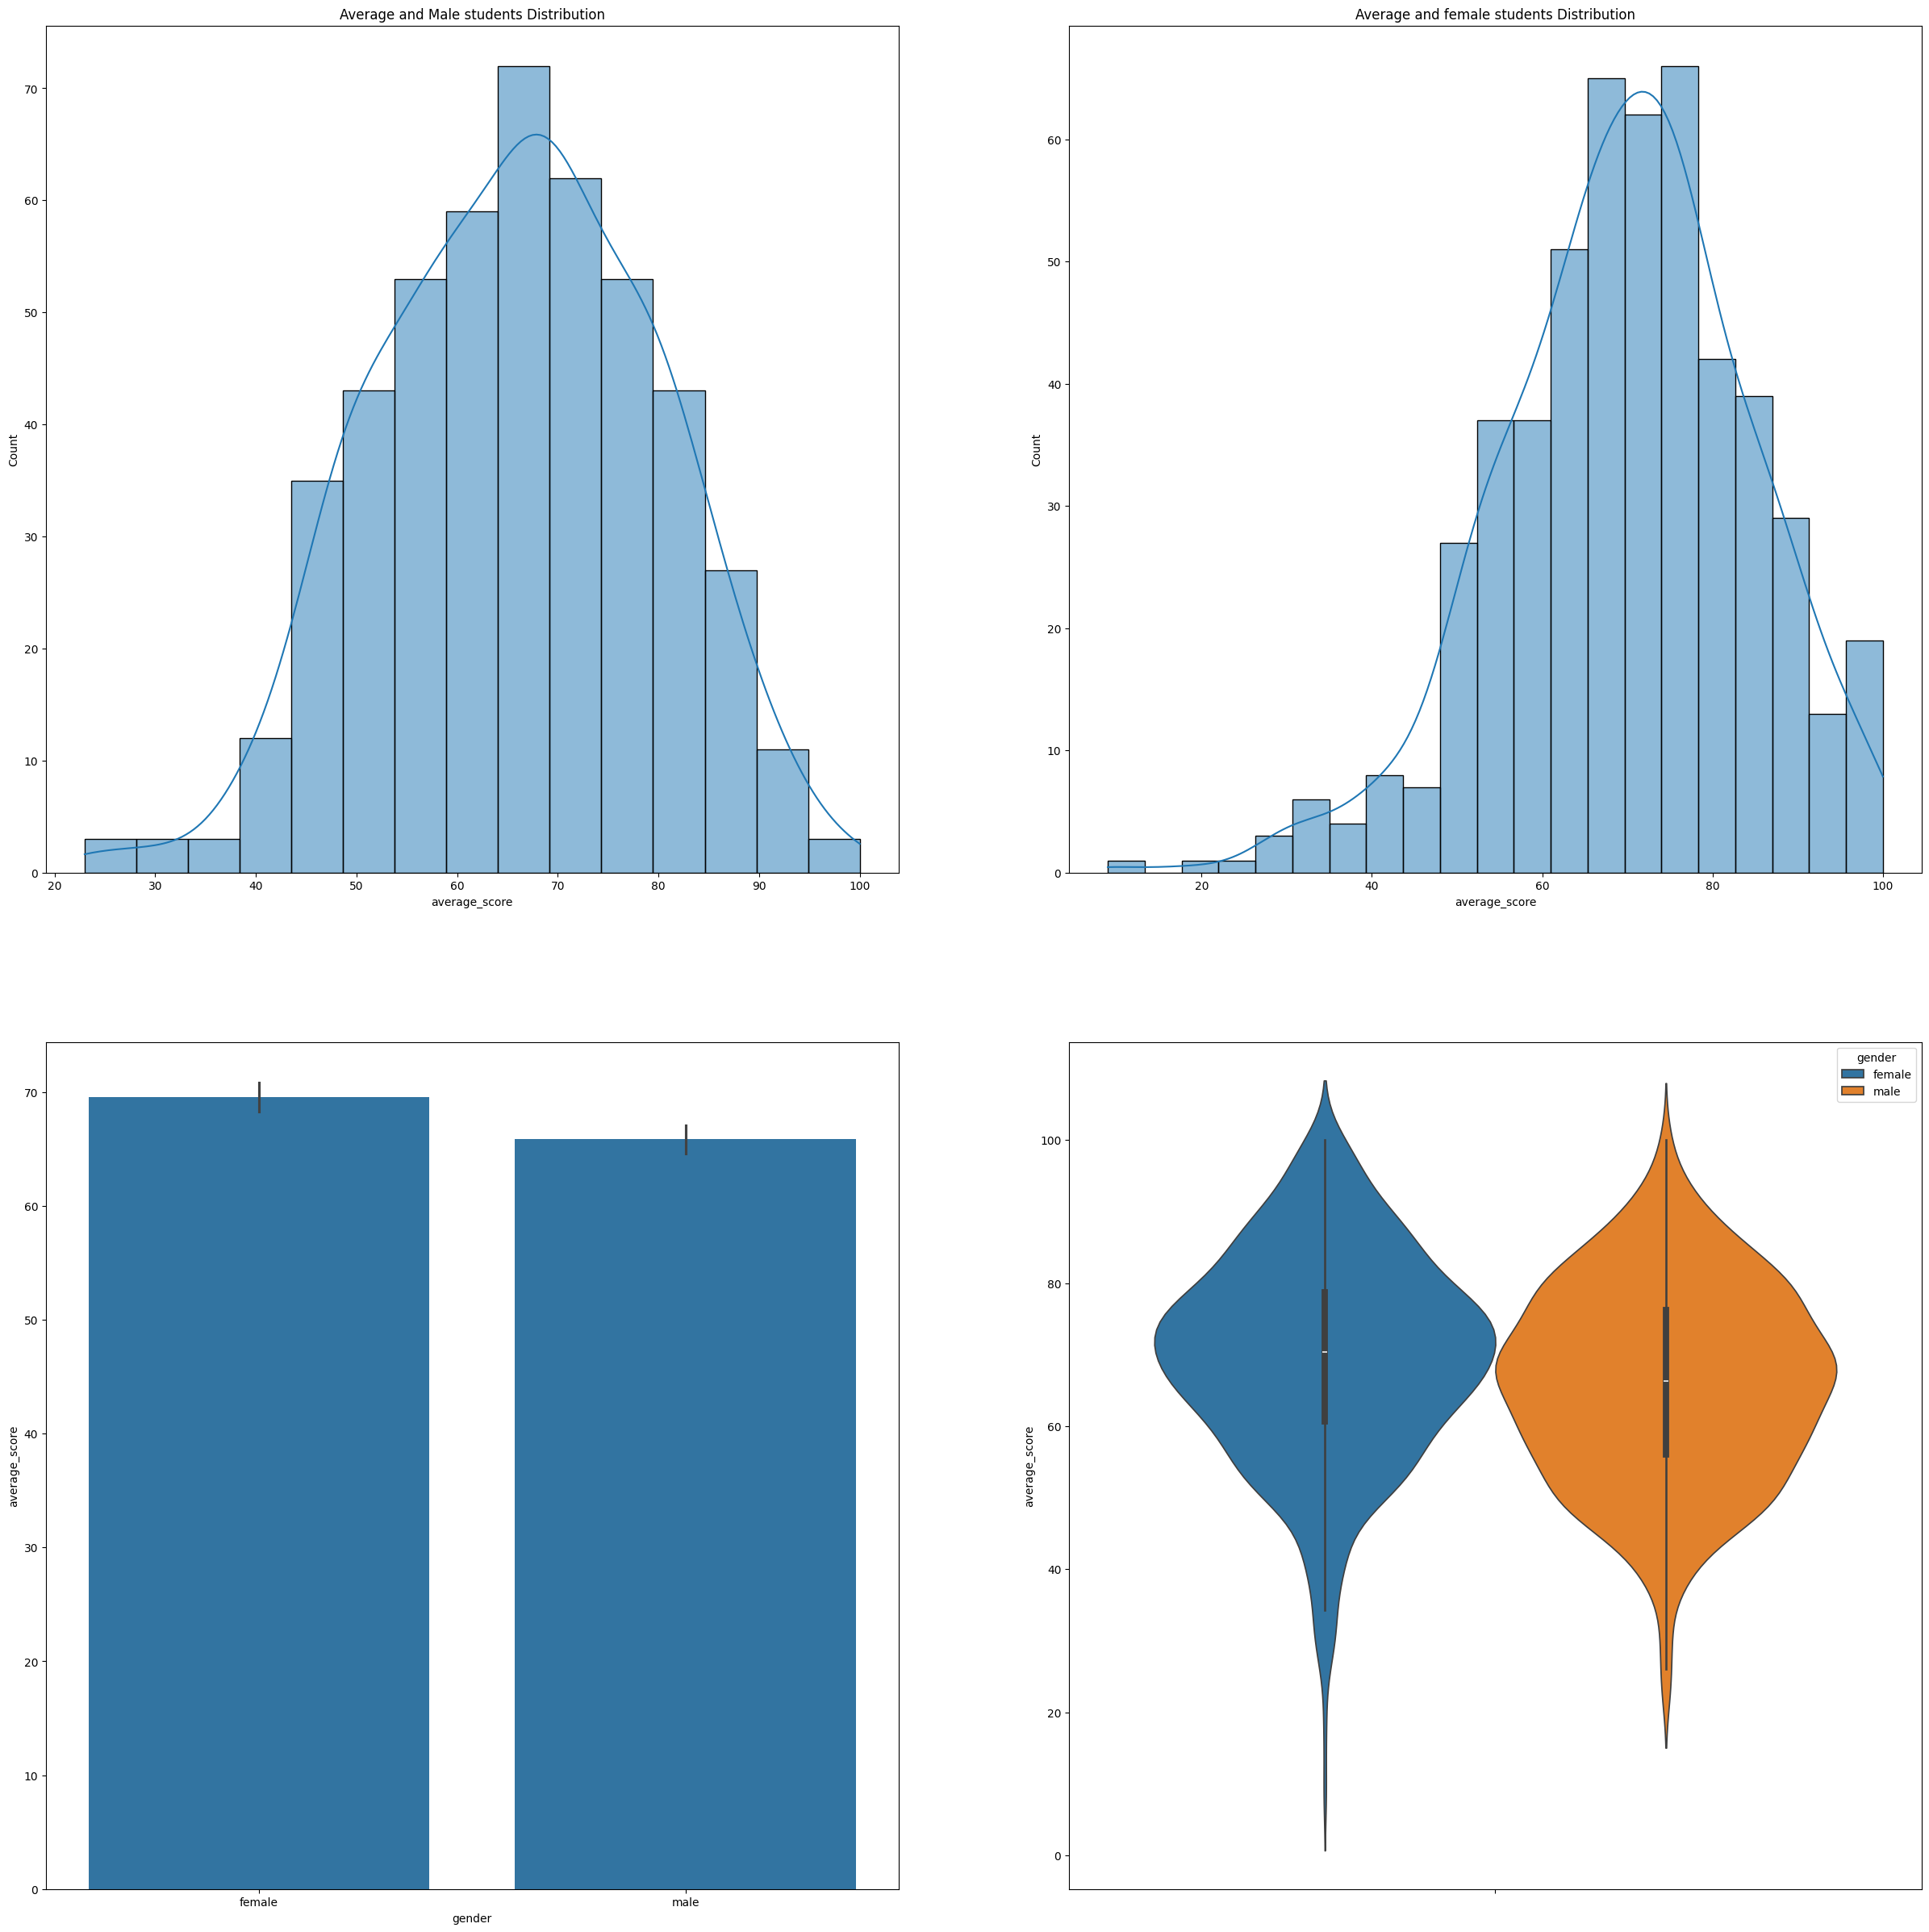

In [16]:
# Gender and average score
fig,ax = plt.subplots(2,2,figsize=(30,30))

plt.subplot(2,2,1)
plt.title("Average and Male students Distribution")
sns.histplot(x="average_score", data=df[df["gender"] == "male"],kde=True)

plt.subplot(2,2,2)
plt.title("Average and female students Distribution")
sns.histplot(x="average_score", data=df[df["gender"] == "female"],kde=True)

plt.subplot(2,2,3)
sns.barplot(x="gender", y="average_score", data=df)

plt.subplot(2,2,4)
sns.violinplot(y="average_score", data=df, hue="gender")


Female students tend to outperform male students in terms of average scores. The distribution of female scores is slightly shifted toward higher values, with a mean around 69–70, while male students have an average score around 65–66. Additionally, male scores exhibit greater variability and more observations in the lower score range.

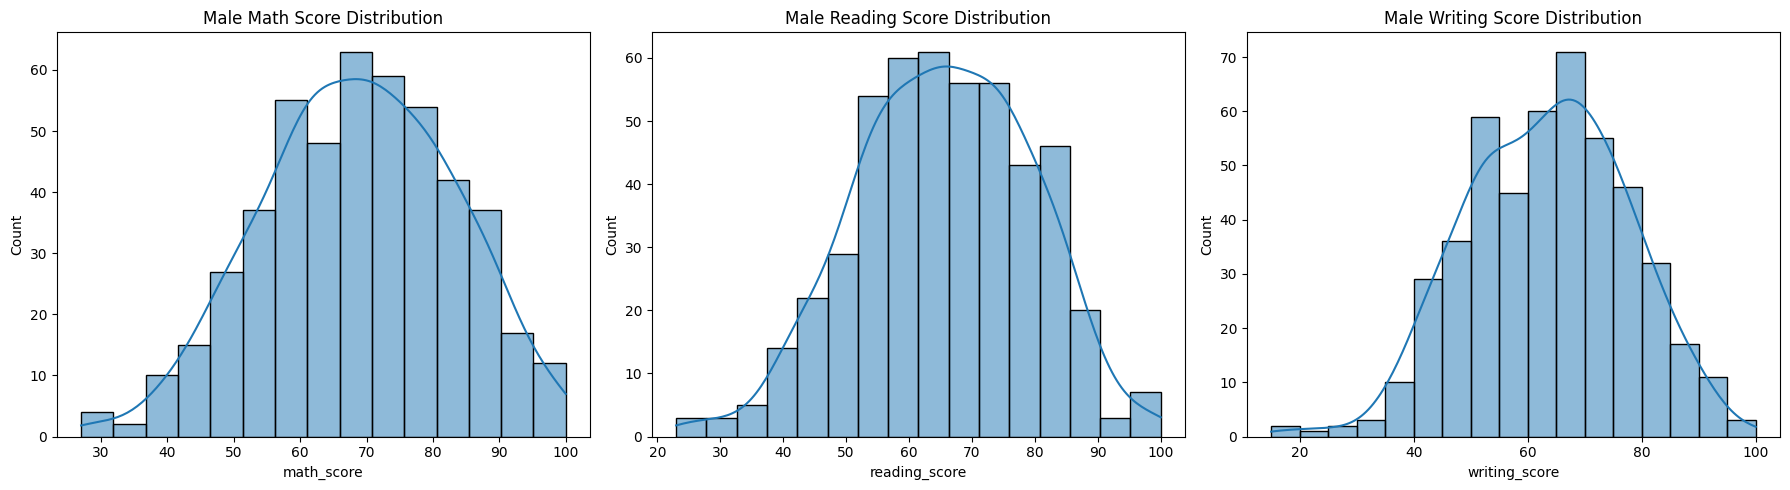

In [18]:
# How individual scores are performing
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(x="math_score", data=df[df["gender"] == "male"], kde=True, ax=axes[0])
axes[0].set_title("Male Math Score Distribution")

sns.histplot(x="reading_score", data=df[df["gender"] == "male"], kde=True, ax=axes[1])
axes[1].set_title("Male Reading Score Distribution")

sns.histplot(x="writing_score", data=df[df["gender"] == "male"], kde=True, ax=axes[2])
axes[2].set_title("Male Writing Score Distribution")

plt.tight_layout()
plt.show()

The score distributions for male students across math, reading, and writing are quite similar. Most male students score between 60 and 80, indicating consistent performance across subjects with no strong subject-specific advantage or disadvantage.

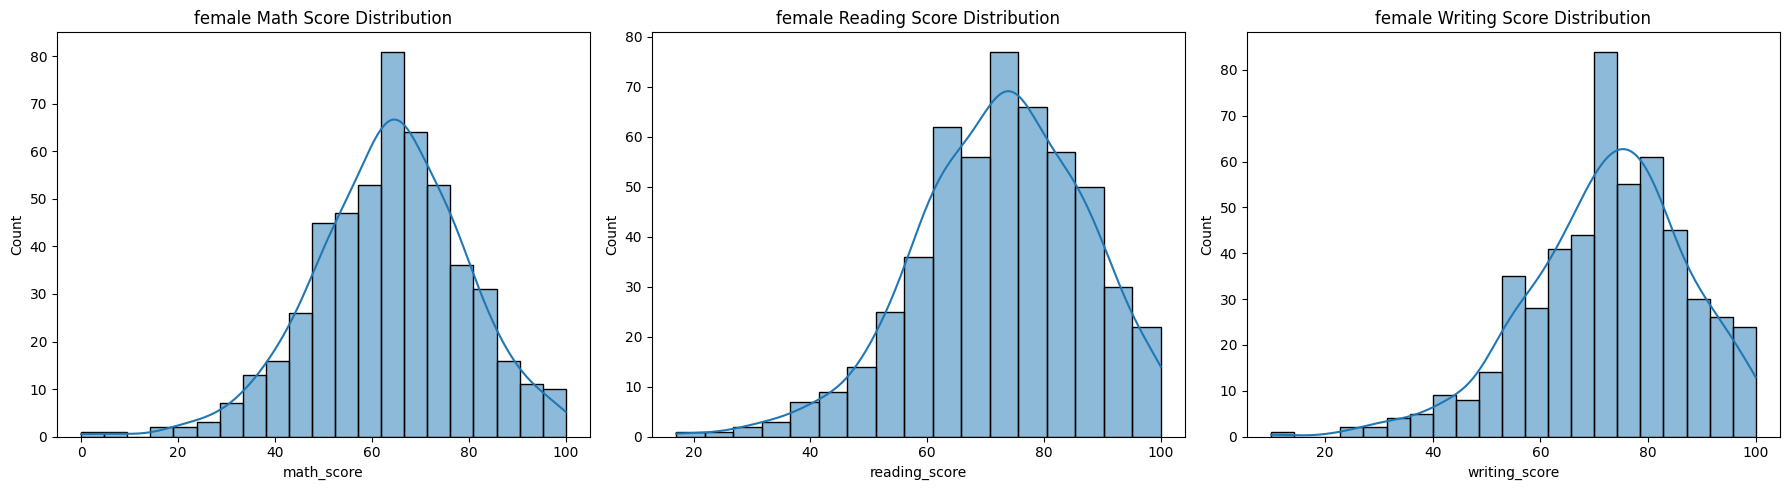

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(x="math_score", data=df[df["gender"] == "female"], kde=True, ax=axes[0])
axes[0].set_title("female Math Score Distribution")

sns.histplot(x="reading_score", data=df[df["gender"] == "female"], kde=True, ax=axes[1])
axes[1].set_title("female Reading Score Distribution")

sns.histplot(x="writing_score", data=df[df["gender"] == "female"], kde=True, ax=axes[2])
axes[2].set_title("female Writing Score Distribution")

plt.tight_layout()
plt.show()

The distribution of scores for female students appears slightly left-skewed, indicating that very few female students have low scores. Most female students score between 60 and 80, suggesting stronger and more consistent performance compared to lower score ranges.

####  Column 2 : Parent Education Level

#### Univariate Analysis

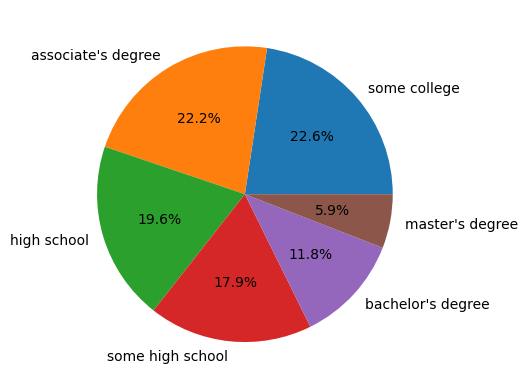

In [27]:
data = df["parental_level_of_education"].value_counts()
labels = data.index

plt.pie(x=data, labels=labels, autopct='%1.1f%%')
plt.show()

The majority of students come from families where parents have completed some college or hold a bachelor’s degree (≈56.6%). A substantial proportion (≈37.5%) have parents with education up to high school, while only a small fraction (≈5%) have parents with a master’s degree. This indicates that highly educated parental backgrounds are relatively underrepresented in the dataset.

#### Bivariate Analysis

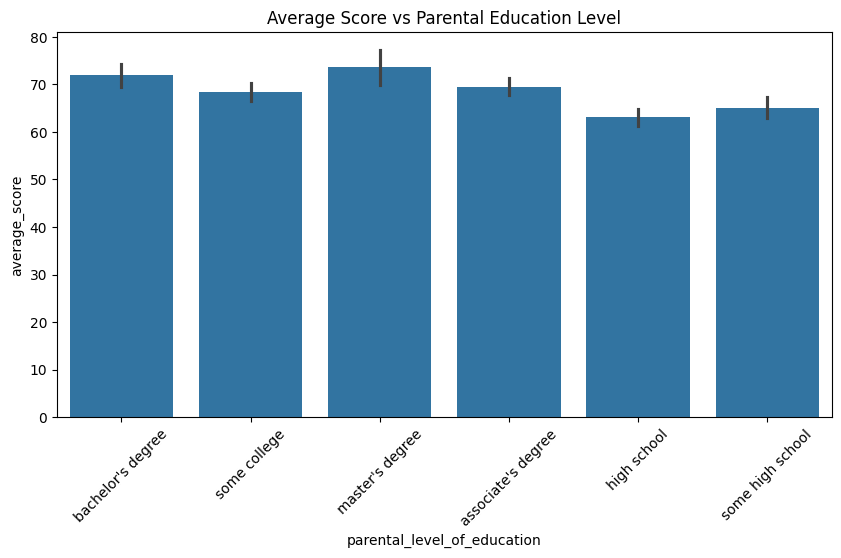

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="parental_level_of_education",
    y="average_score",
    data=df
)

plt.xticks(rotation=45)
plt.title("Average Score vs Parental Education Level")
plt.show()

Students whose parents have higher levels of education tend to achieve slightly higher average scores. In particular, students with parents holding master's or bachelor's degrees show better academic performance compared to students whose parents completed only high school or some high school. However, the differences are moderate, indicating that other factors may also influence student performance.

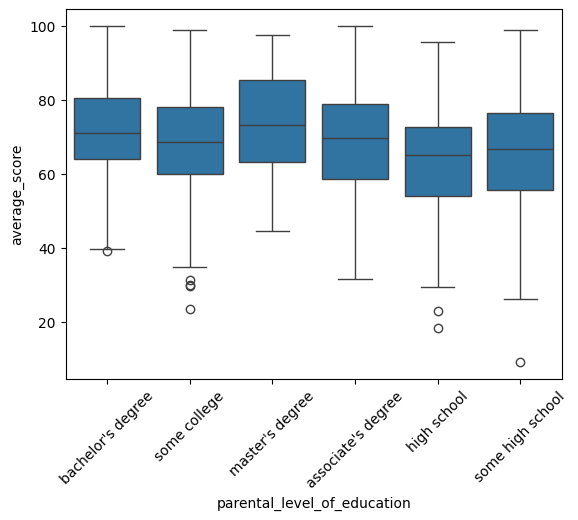

In [29]:
sns.boxplot(
    x="parental_level_of_education",
    y="average_score",
    data=df
)

plt.xticks(rotation=45)
plt.show()

Students whose parents hold a master’s degree tend to achieve the highest average scores. Students whose parents have bachelor’s or associate’s degrees show slightly lower but still relatively strong performance. In contrast, students whose parents have education only up to high school or some high school tend to have the lowest average scores.

In [30]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


#### Column 3: Race or ethinicity

#### Univaritae

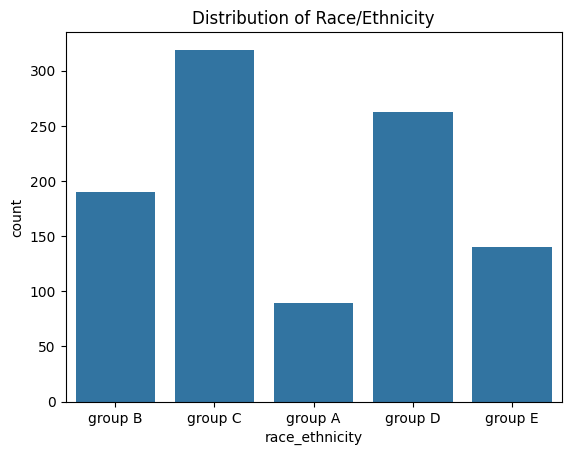

In [31]:
sns.countplot(x="race_ethnicity", data=df)

plt.title("Distribution of Race/Ethnicity")
plt.show()

The race/ethnicity variable consists of five groups (A–E). Group C has the highest representation in the dataset, followed by Groups D and B. Groups E and A have relatively fewer observations, with Group A having the lowest representation. This indicates that the dataset is slightly imbalanced across racial/ethnic groups.

#### Bivariate analysis

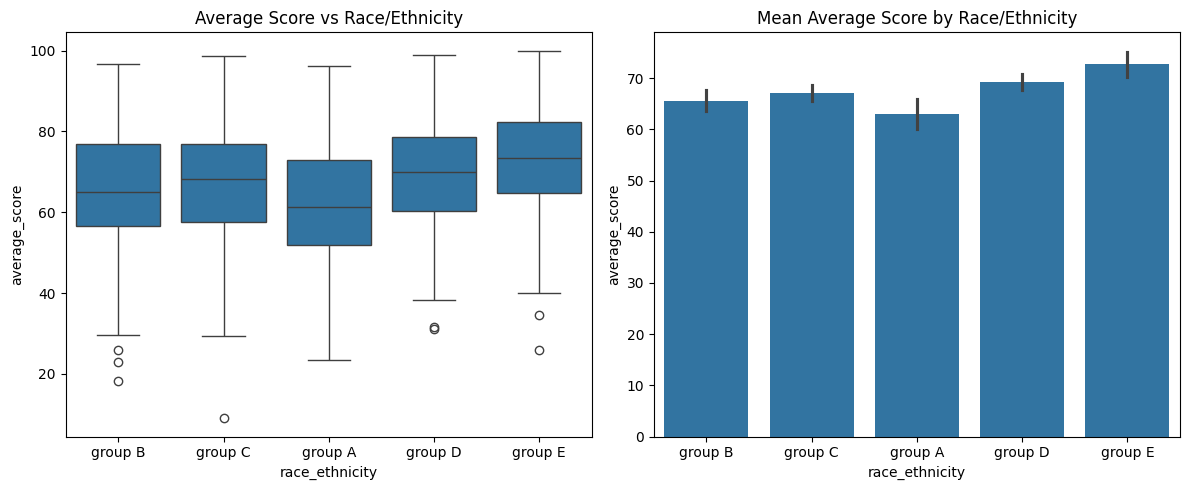

In [35]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x="race_ethnicity", y="average_score", data=df, ax=ax[0])
ax[0].set_title("Average Score vs Race/Ethnicity")

sns.barplot(x="race_ethnicity", y="average_score", data=df, ax=ax[1])
ax[1].set_title("Mean Average Score by Race/Ethnicity")

plt.tight_layout()
plt.show()

Students belonging to Group E and Group D tend to have slightly higher average scores compared to other groups. Group C shows moderate performance, while Group A and Group B tend to have relatively lower average scores. However, the distributions overlap considerably, indicating that race/ethnicity alone does not strongly determine student performance.

#### Column 4 : Lunch

#### Univariate Analysis

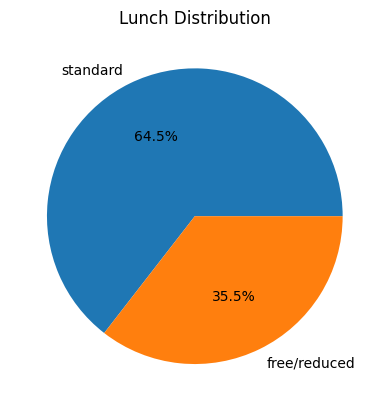

In [37]:
plt.pie(
    df["lunch"].value_counts(),
    labels=df["lunch"].value_counts().index,
    autopct="%1.1f%%"
)

plt.title("Lunch Distribution")
plt.show()

The lunch variable consists of two categories: standard and free/reduced. Approximately 65% of students receive standard lunch, while about 35% receive free or reduced lunch. This indicates that the majority of students in the dataset fall under the standard lunch category.

#### Bivariate Analysis

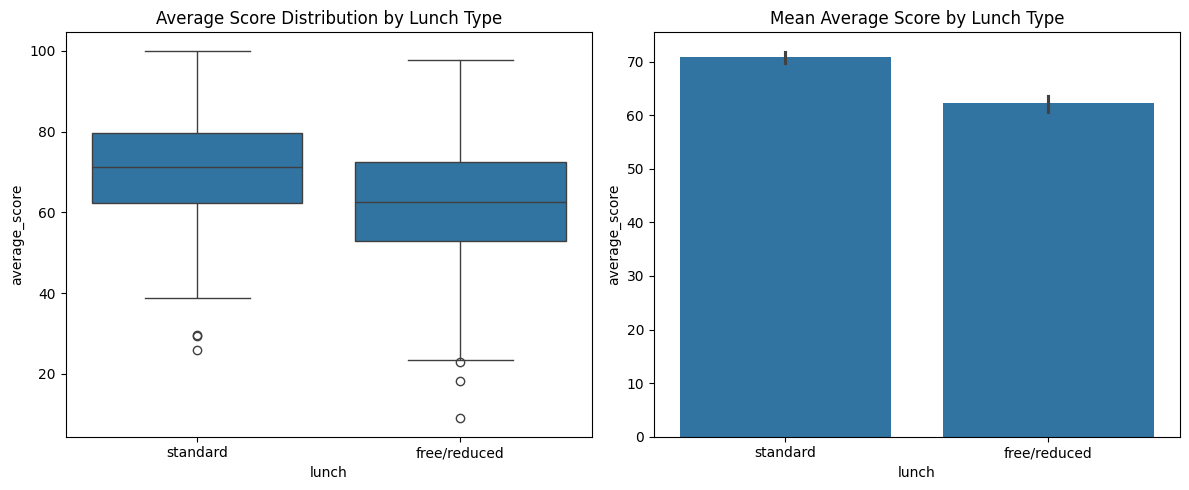

In [38]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Boxplot
sns.boxplot(x="lunch", y="average_score", data=df, ax=ax[0])
ax[0].set_title("Average Score Distribution by Lunch Type")

# Barplot
sns.barplot(x="lunch", y="average_score", data=df, ax=ax[1])
ax[1].set_title("Mean Average Score by Lunch Type")

plt.tight_layout()
plt.show()

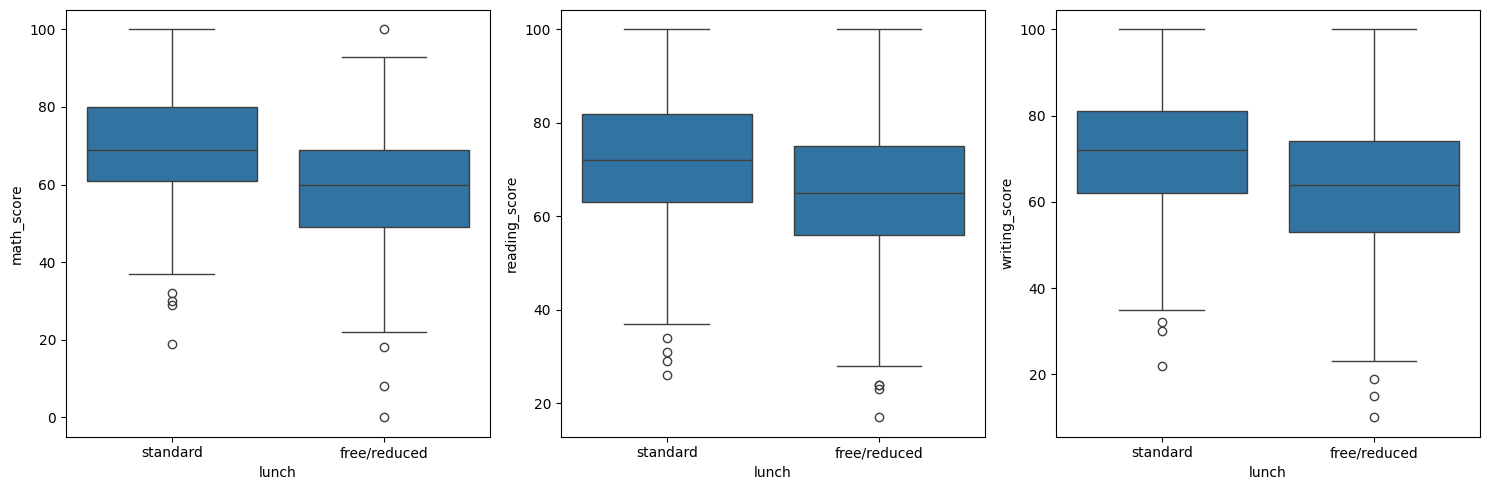

In [39]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(x="lunch", y="math_score", data=df, ax=ax[0])
sns.boxplot(x="lunch", y="reading_score", data=df, ax=ax[1])
sns.boxplot(x="lunch", y="writing_score", data=df, ax=ax[2])

plt.tight_layout()
plt.show()

Students receiving standard lunch tend to have higher average scores compared to students receiving free or reduced lunch, suggesting a possible relationship between lunch type and academic performance.

#### Column 5 : Test Prepration

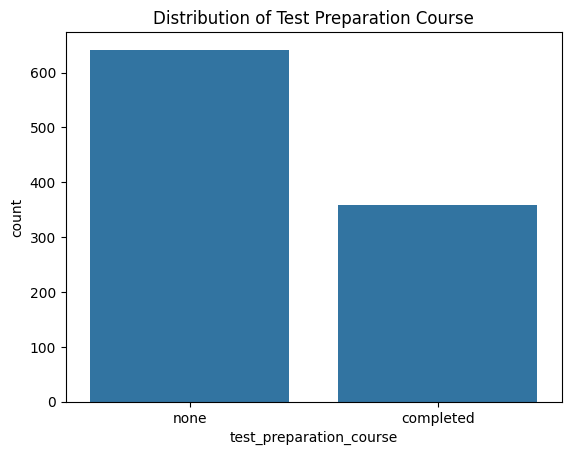

In [40]:
sns.countplot(x="test_preparation_course", data=df)

plt.title("Distribution of Test Preparation Course")
plt.show()

Most students did not complete the test preparation course, while a smaller proportion of students completed it.


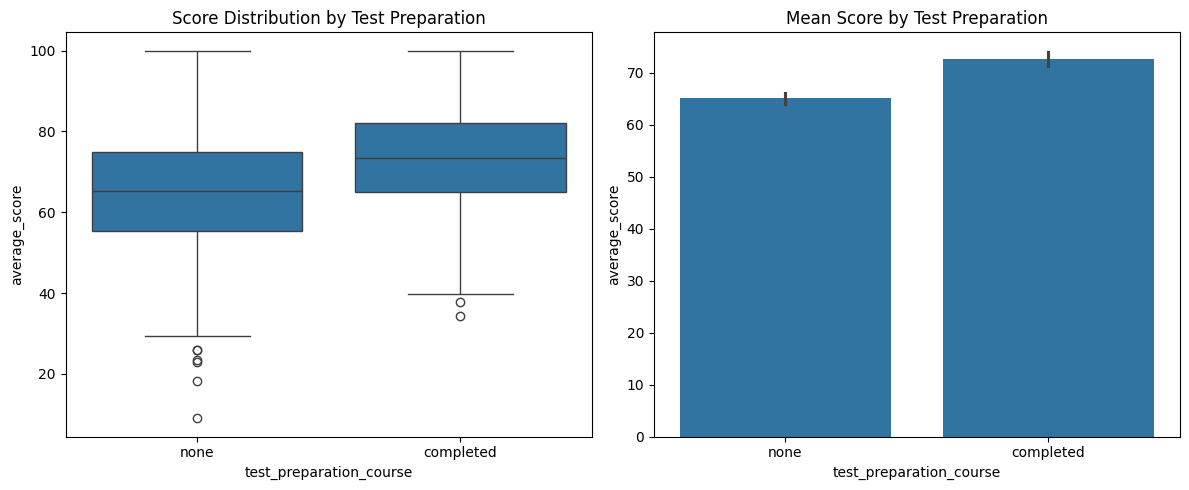

In [41]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Boxplot
sns.boxplot(x="test_preparation_course", y="average_score", data=df, ax=ax[0])
ax[0].set_title("Score Distribution by Test Preparation")

# Barplot
sns.barplot(x="test_preparation_course", y="average_score", data=df, ax=ax[1])
ax[1].set_title("Mean Score by Test Preparation")

plt.tight_layout()
plt.show()

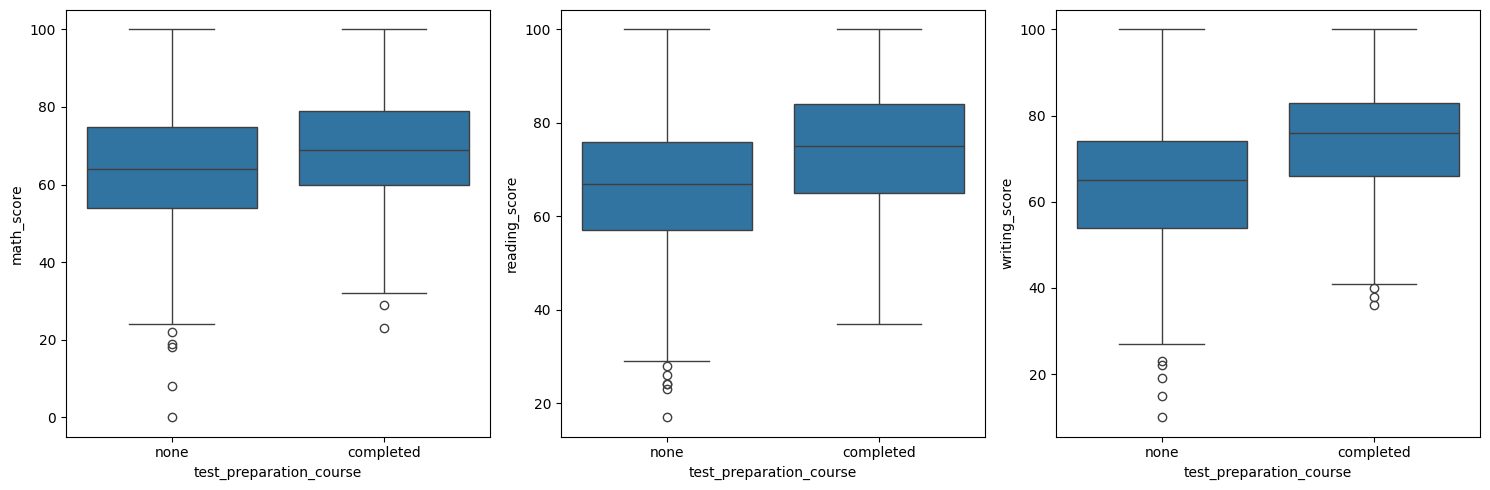

In [42]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(x="test_preparation_course", y="math_score", data=df, ax=ax[0])
sns.boxplot(x="test_preparation_course", y="reading_score", data=df, ax=ax[1])
sns.boxplot(x="test_preparation_course", y="writing_score", data=df, ax=ax[2])

plt.tight_layout()
plt.show()

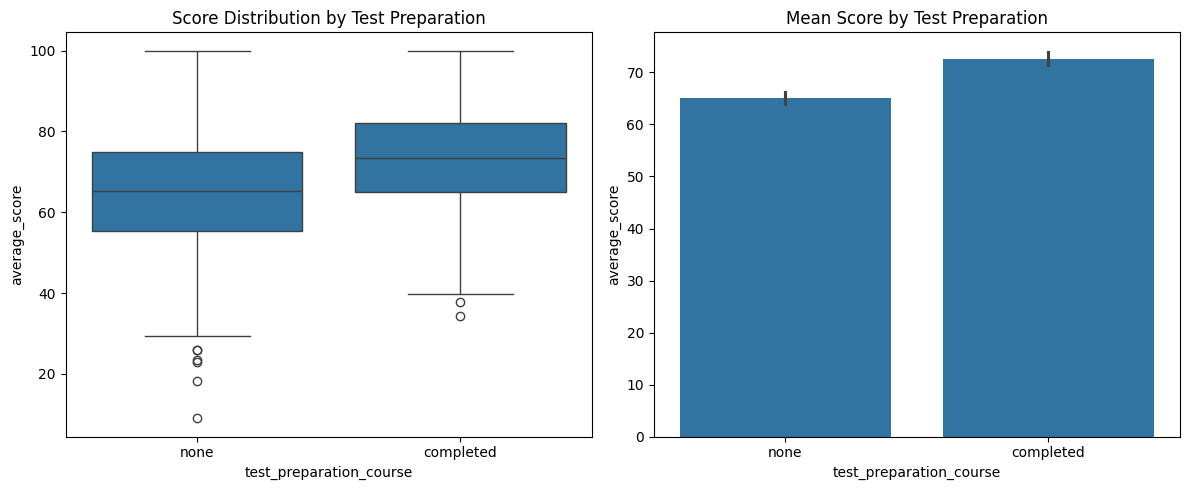

In [43]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Boxplot
sns.boxplot(x="test_preparation_course", y="average_score", data=df, ax=ax[0])
ax[0].set_title("Score Distribution by Test Preparation")

# Barplot
sns.barplot(x="test_preparation_course", y="average_score", data=df, ax=ax[1])
ax[1].set_title("Mean Score by Test Preparation")

plt.tight_layout()
plt.show()

Students who completed the test preparation course tend to have higher average scores compared to students who did not complete it, suggesting that preparation has a positive impact on academic performance.

#### FInal Insight

Test preparation course shows a strong relationship with student scores.
Students who completed the test preparation course generally achieve higher average scores compared to those who did not complete it.

Race/Ethnicity groups D and E tend to have slightly higher average scores compared to other groups, although the differences are moderate.

Parental education level also shows a positive trend with performance.
Students whose parents have bachelor's or master's degrees tend to perform better on average than students whose parents have education only up to high school.

Lunch type may also play a role.
Students receiving standard lunch tend to have higher average scores compared to those receiving free or reduced lunch.